In [1]:
import clip
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from PIL import Image

from classae.sae.batch_topk import BatchTopKSAE
from classae.sae.classae import ClasSAE

In [ ]:
# ---- config ----
CLIP_CKPT = "ViT-L/14"   # swap for whatever backbone your SAE was actually trained on
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load CLIP ----
clip_model, clip_preprocess = clip.load(CLIP_CKPT, device=DEVICE)
clip_model.eval()

CLIP_DIM = clip_model.visual.output_dim

# ---- load an ImageNet-1k val image from HF ----
ds = load_dataset("ILSVRC/imagenet-1k", split="validation")  # gated: needs HF auth token



@torch.no_grad()
def clip_pooled_embedding(pil_image):
    image_input = clip_preprocess(pil_image).unsqueeze(0).to(DEVICE)   # [1, 3, H, W]
    embedding = clip_model.encode_image(image_input)                    # [1, CLIP_DIM]
    return embedding.squeeze(0)                                         # [CLIP_DIM]



Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:


def _get_class_names(class_names_source, num_classes):
    if class_names_source is None:
        return [str(i) for i in range(num_classes)]
    if isinstance(class_names_source, dict):
        names = list(class_names_source.values())
    else:
        names = list(class_names_source)
    if len(names) != num_classes:
        raise ValueError(
            f"Got {len(names)} class names but M has {num_classes} columns — "
            f"check you're not mixing an ImageNet-100 model with the full 1000-class list."
        )
    return names


@torch.no_grad()
def plot_active_claimed_classes(sae, M, x, class_names=None, top_n_classes=15,
                                 weight_mode="activation"):
    """
    Bar chart of the classes most claimed by the features that are ACTIVE on
    this one image's pooled CLIP embedding.

    weight_mode:
      "activation" -- score[c] = sum_i  activation_i * M[i, c]   (default;
                       features that fire harder count for more)
      "mass"       -- score[c] = sum_i  M[i, c]                  (every active
                       feature counted by its raw claim strength, ignoring
                       how hard it fired)
      "count"      -- score[c] = number of active features with M[i, c] > 0.3
                       (crude but easiest to sanity-check by hand)
    """
    if isinstance(M, np.ndarray):
        M = torch.from_numpy(M)
    M = M.float()

    x = x if torch.is_tensor(x) else torch.as_tensor(x)
    x = x.unsqueeze(0) if x.dim() == 1 else x   # sae.encode likely expects a batch dim

    acts = sae.encode(x).squeeze(0).float()   # [d], zeros for inactive
    active_idx = torch.nonzero(acts > 0, as_tuple=True)[0]
    if active_idx.numel() == 0:
        raise ValueError("No active features for this image — nothing to plot.")

    num_classes = M.shape[1]
    class_names = _get_class_names(class_names, num_classes)

    if weight_mode == "activation":
        score = (acts[active_idx].unsqueeze(1) * M[active_idx]).sum(dim=0)
    elif weight_mode == "mass":
        score = M[active_idx].sum(dim=0)
    elif weight_mode == "count":
        score = (M[active_idx] > 0.3).float().sum(dim=0)
    else:
        raise ValueError(f"unknown weight_mode {weight_mode!r}")

    top_vals, top_c = torch.topk(score, k=min(top_n_classes, num_classes))
    labels = [class_names[c] for c in top_c.tolist()]

    fig, ax = plt.subplots(figsize=(8, 0.4 * len(labels) + 1))
    ax.barh(range(len(labels)), top_vals.cpu().numpy(), color="steelblue")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()   # largest at top
    ax.set_xlabel(f"claim score ({weight_mode})")
    ax.set_title(f"Classes most claimed by features active on this image\n"
                 f"({active_idx.numel()} active features)")
    plt.tight_layout()
    return fig, top_c, top_vals


@torch.no_grad()
def plot_active_specialists(sae, M, x, class_names=None, k_max=3.0, top_n=10,
                             claim_thresh=0.3, max_labels_per_feature=4):
    """
    Bar chart of the ACTIVE specialist features (k_i <= k_max) with the
    highest activation on this image, each bar labeled with the classes
    that feature claims.
    """
    if isinstance(M, np.ndarray):
        M = torch.from_numpy(M)
    M = M.float()
    k = M.sum(dim=1)

    x = x if torch.is_tensor(x) else torch.as_tensor(x)
    x = x.unsqueeze(0) if x.dim() == 1 else x

    acts = sae.encode(x).squeeze(0).float()   # [d]

    num_classes = M.shape[1]
    class_names = _get_class_names(class_names, num_classes)

    specialist_active = (acts > 0) & (k <= k_max)
    cand_idx = torch.nonzero(specialist_active, as_tuple=True)[0]
    if cand_idx.numel() == 0:
        raise ValueError(
            f"No active specialist features with k_i <= {k_max} on this image — "
            f"try raising k_max, or this image just doesn't route through any specialists."
        )

    n_top = min(top_n, cand_idx.numel())
    top_vals, local_order = torch.topk(acts[cand_idx], k=n_top, largest=True, sorted=True)
    top_idx = cand_idx[local_order]

    row_labels = []
    for f in top_idx.tolist():
        claimed = torch.nonzero(M[f] > claim_thresh, as_tuple=True)[0]
        claimed_sorted = claimed[torch.argsort(-M[f, claimed])][:max_labels_per_feature]
        names = [class_names[c] for c in claimed_sorted.tolist()]
        suffix = f" (+{len(claimed) - len(names)} more)" if len(claimed) > len(names) else ""
        row_labels.append(f"feat {f}  k_i={k[f].item():.1f}: " + ", ".join(names) + suffix)

    fig, ax = plt.subplots(figsize=(9, 0.5 * n_top + 1))
    ax.barh(range(n_top), top_vals.cpu().numpy(), color="darkorange")
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("activation")
    ax.set_title(f"Active specialist features (k_i \u2264 {k_max}), highest activation first")
    plt.tight_layout()
    return fig, top_idx, top_vals


# usage:
# from imagenet_classes import IMAGENET2012_CLASSES
# names = list(IMAGENET2012_CLASSES.values())
# fig1, *_ = plot_active_claimed_classes(sae, M, clip_embedding, class_names=names)
# fig2, *_ = plot_active_specialists(sae, M, clip_embedding, class_names=names, k_max=3.0)

In [4]:
from classae.labels import IMAGENET2012_CLASSES
names = list(IMAGENET2012_CLASSES.values())

In [5]:
from classae.eval.posthoc_M import build_posthoc_M


c_sae = ClasSAE.from_pretrained("../checkpoints/clip_16384/classae_42_16384/")
c_sae.eval()
M_c = c_sae.calculate_M().detach()

b_sae= BatchTopKSAE.from_pretrained("../checkpoints/clip_16384/batch_topk_42_16384/")
b_sae.eval()
M_b, k = build_posthoc_M(torch.load("../experiment_results/empirical_matrices/batch_topk_42_16384.pth"), 40)

In [6]:
sample = ds[102]
image = sample["image"].convert("RGB")
true_label = sample["label"]
x = clip_pooled_embedding(image)
assert x.shape[0] == CLIP_DIM

earthstar


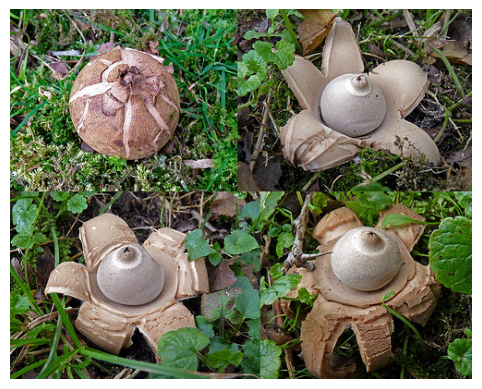

(<Figure size 800x500 with 1 Axes>,
 tensor([916, 921, 917, 458, 922, 610, 781, 838, 692, 631]),
 tensor([410.0699, 408.8087, 407.7460, 406.8632, 405.9485, 404.0645, 401.5464,
         401.3419, 400.6457, 400.2519]))

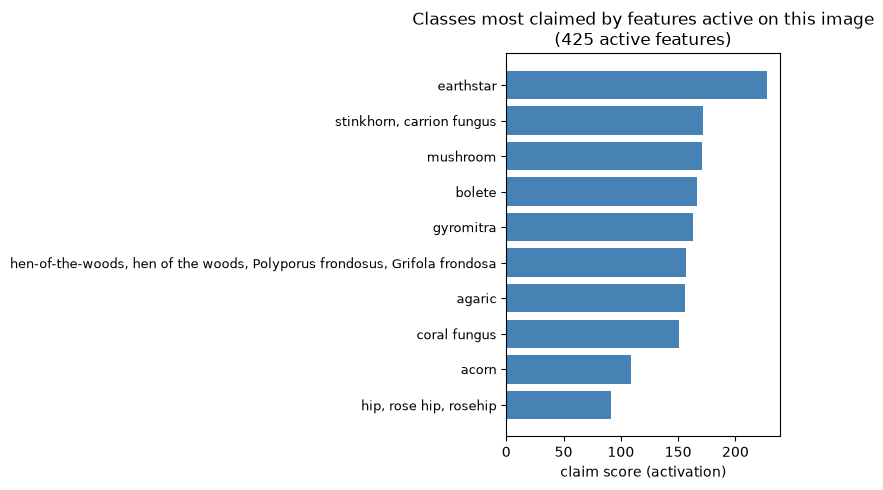

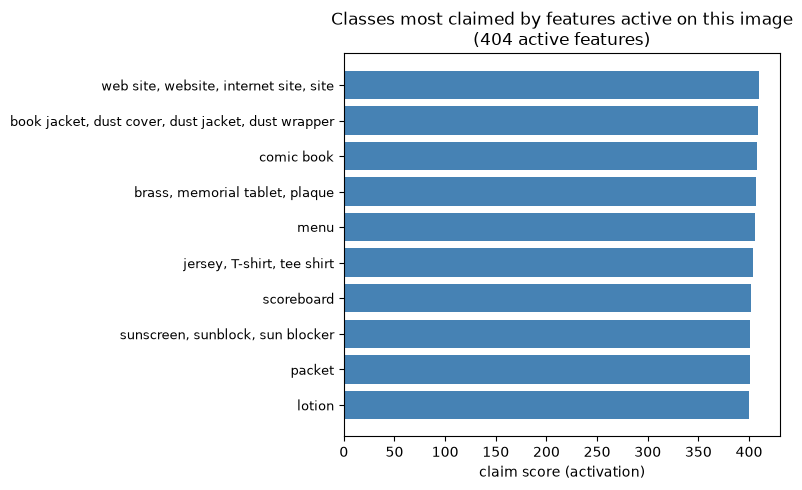

In [7]:
print(names[true_label])
plt.imshow(image)
plt.axis('off')
plt.show()
plot_active_claimed_classes(c_sae, M_c, x, class_names=names, top_n_classes=10, weight_mode="activation")
plot_active_claimed_classes(b_sae, M_b, x.cpu(), class_names=names, top_n_classes=10, weight_mode="activation")

(<Figure size 900x200 with 1 Axes>,
 tensor([3893, 2010]),
 tensor([0.8909, 0.2762]))

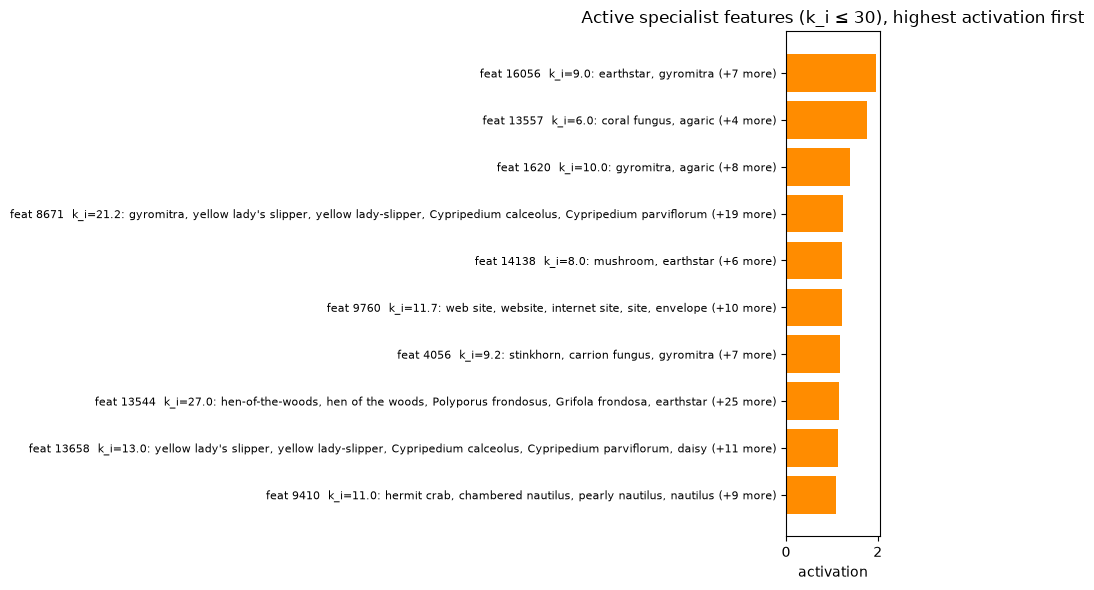

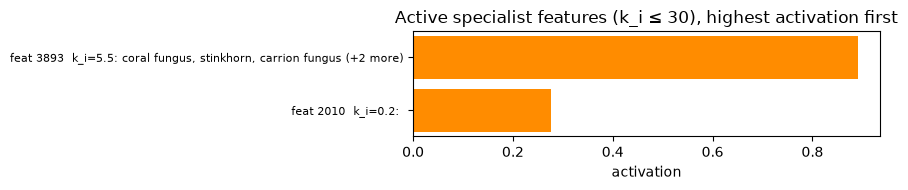

In [8]:
plot_active_specialists(c_sae, M_c, x, names, k_max=30, claim_thresh=0.7, max_labels_per_feature=2)
plot_active_specialists(b_sae, M_b, x.cpu(), names, k_max=30, claim_thresh=0.7, max_labels_per_feature=2)

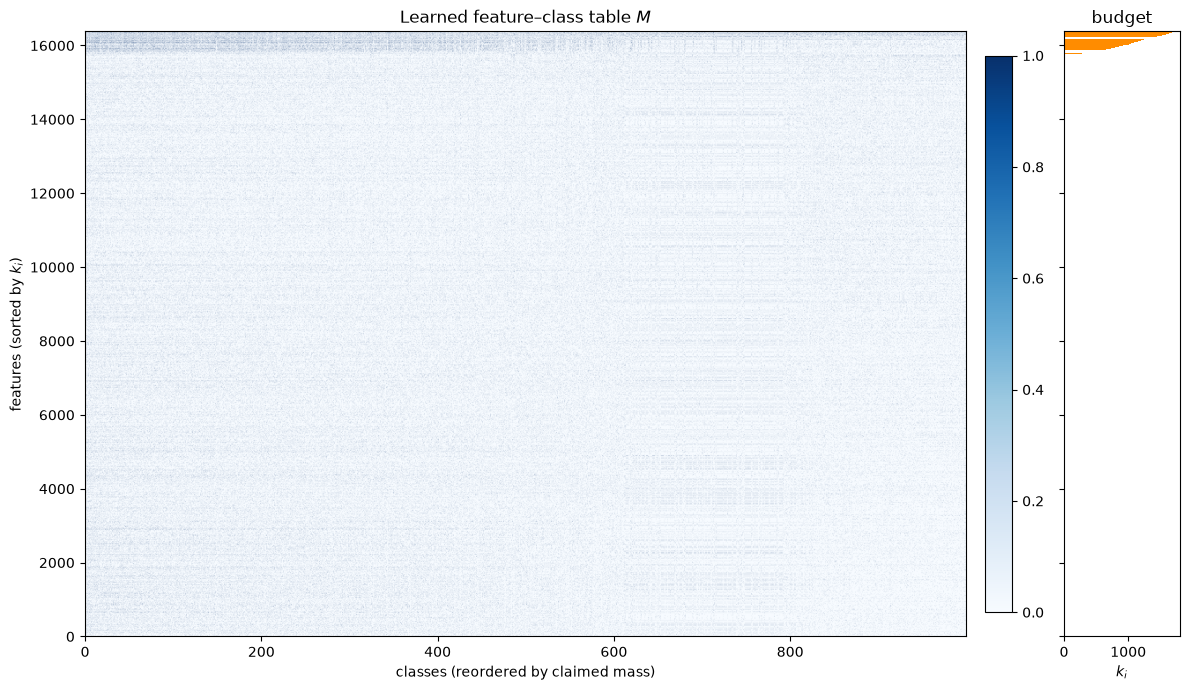

In [9]:
M = M_c.cpu().numpy()
row_order = np.argsort(k)  # specialists -> generalists
M, k = M[row_order], k[row_order]

col_order = np.argsort(-M.sum(axis=0))  # busiest classes first
M = M[:, col_order]

fig, (ax_m, ax_k) = plt.subplots(
    1, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [8, 1]}, sharey=True
)
im = ax_m.imshow(M, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_m.set_xlabel("classes (reordered by claimed mass)")
ax_m.set_ylabel(r"features (sorted by $k_i$)")
ax_m.set_title("Learned feature–class table $M$")
fig.colorbar(im, ax=ax_m, fraction=0.03, pad=0.02)

ax_k.barh(range(len(k)), k, color="darkorange")
ax_k.invert_yaxis()  # keep row 0 (smallest k_i) at the top
ax_k.set_xlabel(r"$k_i$")
ax_k.set_title("budget")

plt.tight_layout()

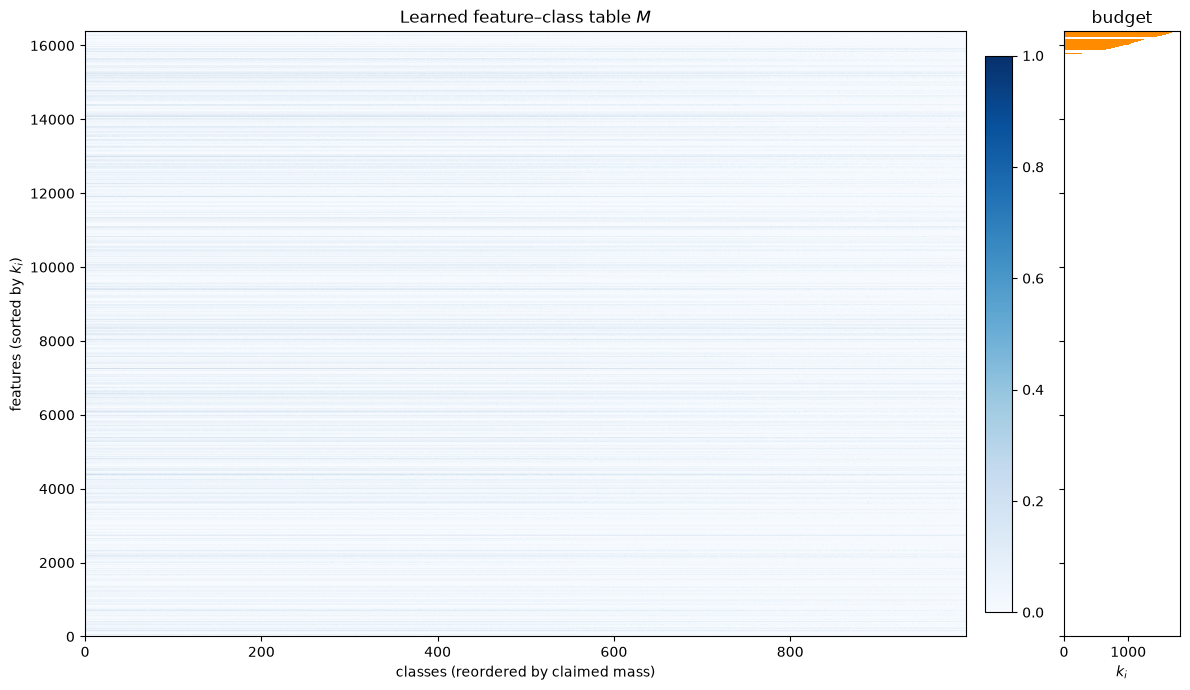

In [10]:
M = M_b.numpy()

row_order = np.argsort(k)  # specialists -> generalists
M, k = M[row_order], k[row_order]

col_order = np.argsort(-M.sum(axis=0))  # busiest classes first
M = M[:, col_order]

fig, (ax_m, ax_k) = plt.subplots(
    1, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [8, 1]}, sharey=True
)
im = ax_m.imshow(M, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_m.set_xlabel("classes (reordered by claimed mass)")
ax_m.set_ylabel(r"features (sorted by $k_i$)")
ax_m.set_title("Learned feature–class table $M$")
fig.colorbar(im, ax=ax_m, fraction=0.03, pad=0.02)

ax_k.barh(range(len(k)), k, color="darkorange")
ax_k.invert_yaxis()  # keep row 0 (smallest k_i) at the top
ax_k.set_xlabel(r"$k_i$")
ax_k.set_title("budget")

plt.tight_layout()